# Deep Dive Exploratory Data Analysis

## CRISP-DM Phase 5: Deep Dive Exploratory Data Analysis

### Project: Customer Churn Analysis

Deep Dive Exploratory Data Analysis is the process of performing a detailed investigation of the cleaned customer churn dataset to uncover deeper patterns, relationships, customer segments, and behavioral factors that may contribute to customer churn.

The objectives of this notebook are to:

- Load the cleaned customer churn dataset
- Perform detailed analysis of customer demographics and characteristics
- Investigate churn patterns across different customer segments
- Analyze the impact of customer tenure on churn
- Examine the relationship between services and customer churn
- Analyze the impact of contract type on churn
- Investigate payment methods and their relationship with churn
- Analyze monthly and total charges across churn categories
- Examine interactions between multiple features and churn
- Perform detailed numerical and categorical feature analysis
- Identify high-risk customer segments
- Investigate potential drivers and indicators of churn
- Analyze churn rates using grouped and segmented analysis
- Explore feature interactions using advanced visualizations
- Identify statistically and practically significant patterns
- Generate actionable business insights from the analysis
- Prepare important findings for feature selection and subsequent modeling

### Input
Cleaned customer churn dataset

### Output
A detailed exploratory analysis containing advanced visualizations, customer segments, feature relationships, churn drivers, high-risk groups, and actionable business insights.

### Key Areas of Analysis

- **Customer Segmentation:** Identify groups of customers with similar characteristics and churn behavior
- **Tenure Analysis:** Examine how customer tenure influences churn probability
- **Service Analysis:** Investigate how subscribed services affect customer retention
- **Contract Analysis:** Analyze churn behavior across different contract types
- **Payment Analysis:** Examine the relationship between payment methods and churn
- **Revenue Analysis:** Investigate monthly and total charges associated with churn
- **Feature Interaction Analysis:** Explore combinations of variables that may increase churn risk
- **Segment-Level Churn Analysis:** Compare churn rates across different customer groups
- **High-Risk Customer Analysis:** Identify customer profiles with a higher likelihood of churn
- **Correlation and Association Analysis:** Investigate relationships between important features
- **Statistical Analysis:** Validate important patterns and differences observed during EDA
- **Business Insights:** Translate deep analytical findings into actionable strategies for customer retention

### Expected Insights

The deep dive analysis should help answer questions such as:

- Which customer segments have the highest churn rate?
- Does customer tenure influence churn?
- Which contract types are most associated with churn?
- Which services are associated with higher or lower churn?
- Does payment method influence customer retention?
- How do monthly and total charges differ between churned and retained customers?
- Which combinations of customer characteristics indicate higher churn risk?
- What are the strongest potential drivers of customer churn?
- Which customer segments should be prioritized for retention strategies?

### Conclusion

The findings from the Deep Dive EDA will be used to identify the most relevant features, understand the key drivers of customer churn, and support feature engineering and machine learning model development in the subsequent phases.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
engine = create_engine(
    f"postgresql://{DB_CONFIG["user"]}:{DB_CONFIG["password"]}@{DB_CONFIG["host"]}:{DB_CONFIG["port"]}/{DB_CONFIG["database"]}"
)

query = "SELECT * FROM customer_churn_clean_eda;"
customer_churn = pd.read_sql(query, engine)

customer_churn.head()

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [4]:
def capitalize_first(text):
    return text[0].upper() + text[1:]

In [5]:
# Reusable function
def calculate_churn_percentage(customer_churn, column):
    churn_pct = customer_churn.groupby(column)['churn_label'].apply(
    lambda x: (x == 'Yes').mean() * 100)
    
    ax = sns.barplot(x=churn_pct.index, y=churn_pct.values)

    plt.title(f'Churn Percentage by {capitalize_first(column)}')
    plt.xlabel(f'{capitalize_first(column)}')
    plt.ylabel('Churn Percentage (%)')
    plt.ylim(0, 100)
    
    for i, value in enumerate(churn_pct.values):
        ax.text(i, value + 1, f'{value:.1f}%', ha='center')

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    

## 1. How do gender, senior-citizen status, partner status, and dependent status influence customer churn?

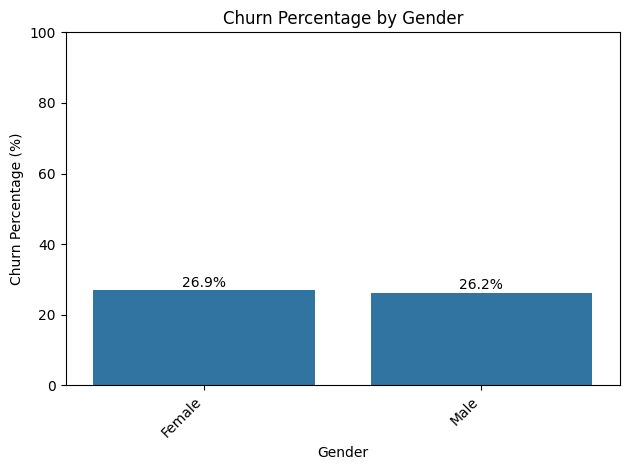

In [6]:
# Gender vs churn rate
calculate_churn_percentage(customer_churn, 'gender')

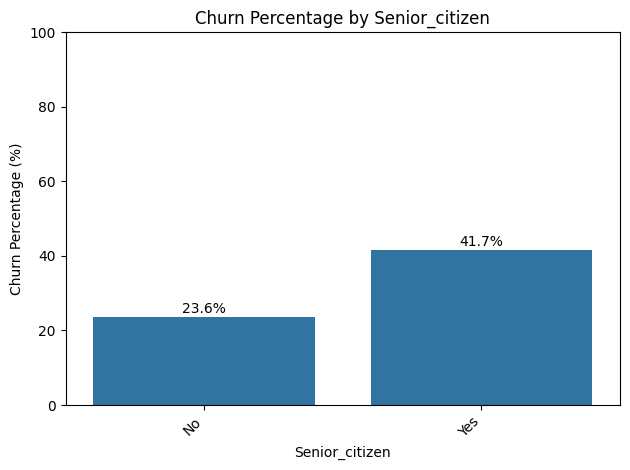

In [7]:
calculate_churn_percentage(customer_churn, 'senior_citizen')

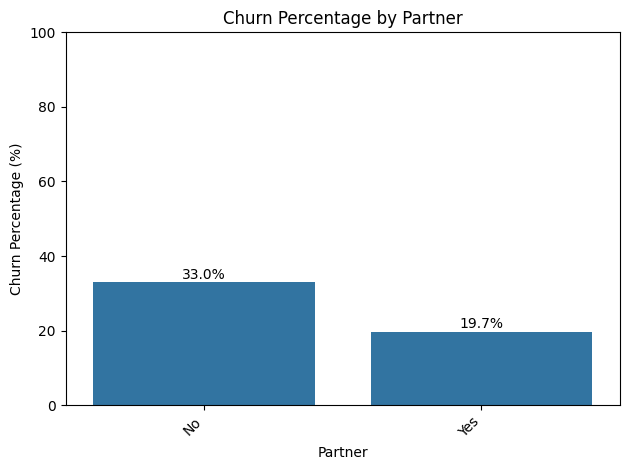

In [8]:
calculate_churn_percentage(customer_churn, 'partner')

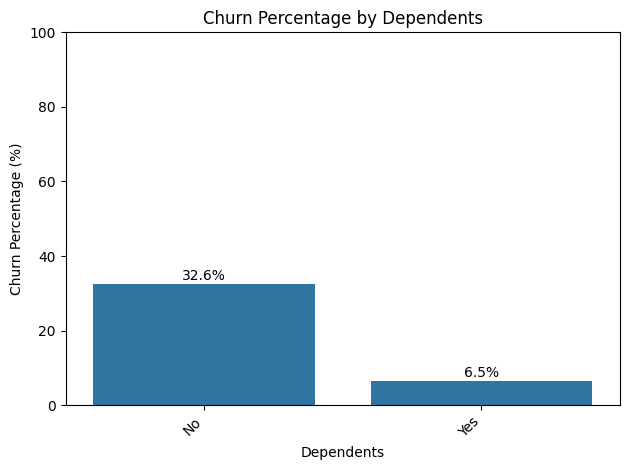

In [9]:
calculate_churn_percentage(customer_churn, 'dependents')

### 1.1. How do senior-citizen and partner status jointly influence customer churn?

In [10]:
customer_churn['is_churned'] = customer_churn['churn_label'] == 'Yes'

In [11]:
churn_pct = (
    customer_churn.groupby(['senior_citizen', 'partner'])['is_churned']
    .mean()
    .unstack() * 100
)

churn_pct

partner,No,Yes
senior_citizen,,
No,30.013021,16.648993
Yes,48.857645,34.554974


### 1.2. How do senior citizen and dependent status jointly influence customer churn?

In [12]:
churn_pct = (
    customer_churn.groupby(['senior_citizen', 'dependents'])['is_churned']
    .mean()
    .unstack() * 100
)

churn_pct

dependents,No,Yes
senior_citizen,,
No,29.882678,6.048906
Yes,43.405051,16.438356


#### Initial Observations

* **Gender:** Churn rates between male and female customers are relatively similar, suggesting that gender has a limited association with customer churn.

* **Senior Citizen Status:** Senior citizens have a higher churn rate than non-senior customers, indicating that senior-citizen status is associated with a greater likelihood of churn.

* **Partner Status:** Customers without a partner tend to have a higher churn rate than those with a partner, suggesting that customers with partners may be more likely to remain with the company.

* **Dependent Status:** Customers without dependents generally have a higher churn rate than customers with dependents, indicating an association between having dependents and greater customer retention.

* **Senior Citizen and Partner Status:** Senior citizens without a partner have the **highest churn rate (48.9%)**, while non-senior customers with a partner have the **lowest churn rate (16.6%)**. This suggests that the combination of senior-citizen status and not having a partner is associated with a higher risk of churn.

* **Senior Citizen and Dependent Status:** Churn is higher among **senior citizens without dependents (43.4%)** and lowest among **non-senior customers with dependents (6.0%)**. This indicates that senior-citizen status and dependent status may jointly be associated with differences in customer churn.

* **Overall:** Among the demographic characteristics analyzed, **senior-citizen status, partner status, and dependent status** show more noticeable differences in churn rates than gender. These findings indicate **associations rather than causal relationships** and should be further investigated using statistical analysis and machine learning models.


## 2. What is the distribution of customer churn rates across different contract types?

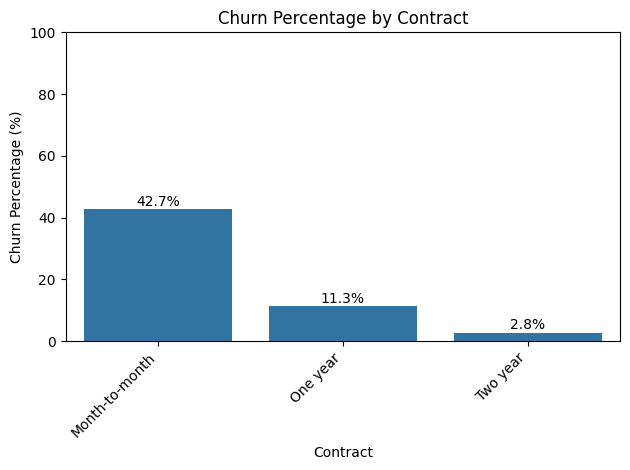

In [13]:
calculate_churn_percentage(customer_churn, 'contract')

### 2.1. Does gender and contract type jointly influence customer churn?

In [14]:
churn_by_contract_gender = (
    customer_churn.groupby(['contract', 'gender'])['is_churned']
    .mean()
    .unstack() * 100
)
churn_by_contract_gender

gender,Female,Male
contract,,
Month-to-month,43.740260,41.692308
One year,10.445682,12.052980
Two year,2.603550,3.058824


### 2.2. Does partner and contract type jointly influence customer churn?

In [15]:
churn_by_contract_partner  = (
    customer_churn.groupby(['contract', 'partner'])['is_churned']
    .mean()
    .unstack() * 100
)
churn_by_contract_partner

partner,No,Yes
contract,,
Month-to-month,44.689379,39.130435
One year,10.575428,11.807229
Two year,3.379722,2.600671


### 2.3. Does dependents and contract type jointly influence customer churn?

In [16]:
churn_by_contract_dependents = (
    customer_churn.groupby(['contract', 'dependents'])['is_churned']
    .mean()
    .unstack() * 100
)
churn_by_contract_partner

partner,No,Yes
contract,,
Month-to-month,44.689379,39.130435
One year,10.575428,11.807229
Two year,3.379722,2.600671


In [17]:
customer_churn['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

#### Initial Observations

* **Contract Type:** Customer churn decreases substantially as contract length increases. Customers on **month-to-month contracts have the highest churn rate (42.7%)**, compared with **11.3% for one-year contracts** and just **2.8% for two-year contracts**.

* **Overall:** Contract type shows a strong association with customer churn, with customers on longer-term contracts being considerably less likely to churn. This suggests that contract type may be an important feature for predicting customer churn.

* While contract type was also explored alongside **gender, partner status, and dependent status**, these additional combinations did not provide substantial insights beyond the strong relationship already observed between contract type and churn.

## 3. How do payment methods and paperless billing relate to customer churn rates? 

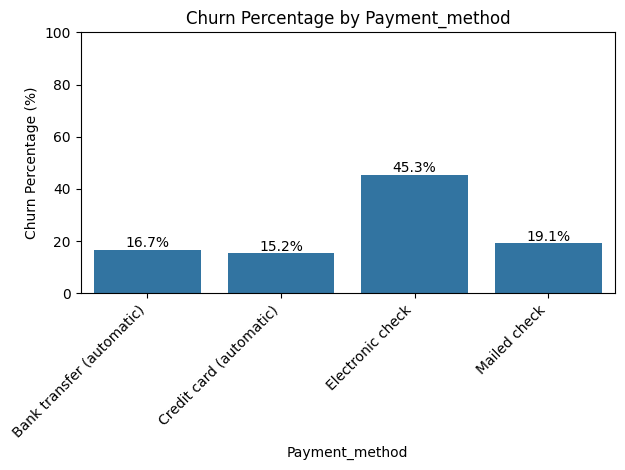

In [18]:
calculate_churn_percentage(customer_churn, 'payment_method')

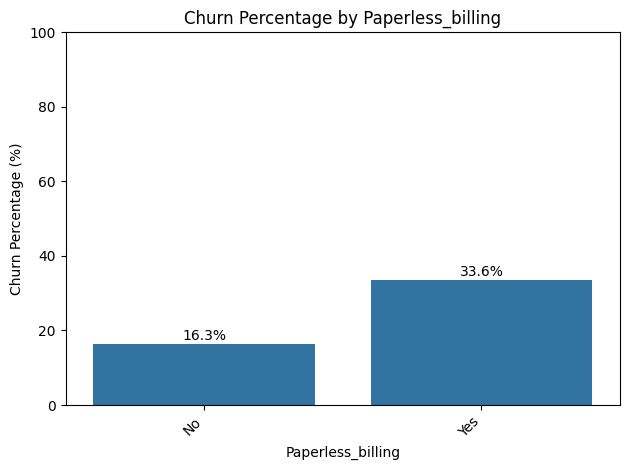

In [19]:
calculate_churn_percentage(customer_churn, 'paperless_billing')

### Initial Observation

* **Payment Method:** Customers using **Electronic Check** have a relatively high churn rate of **45.3%**, suggesting that this payment method may be associated with increased customer churn.
* **Paperless Billing:** Customers with **Paperless Billing** have a churn rate of **33.6%**, indicating a moderate level of churn among these customers.
* **Initial Insight:** Electronic Check users appear to have a **higher churn rate** than customers with paperless billing. However, these observations show **association rather than causation**, so further analysis is needed to understand whether payment method and billing preferences are significant drivers of churn.


## 4. How does monthly charge vary between churned and retained customers?

In [20]:
customer_churn.groupby('is_churned')['monthly_charges'].mean()

is_churned
False    61.265124
True     74.441332
Name: monthly_charges, dtype: float64

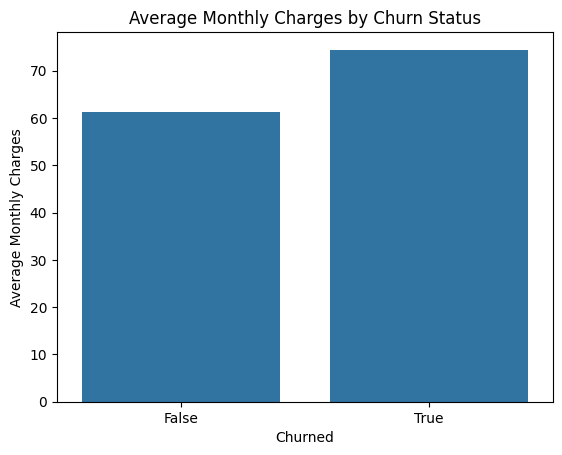

In [21]:
sns.barplot(
    data=customer_churn,
    x='is_churned',
    y='monthly_charges',
    estimator='mean',
    errorbar=None
)

plt.xlabel('Churned')
plt.ylabel('Average Monthly Charges')
plt.title('Average Monthly Charges by Churn Status')
plt.show()

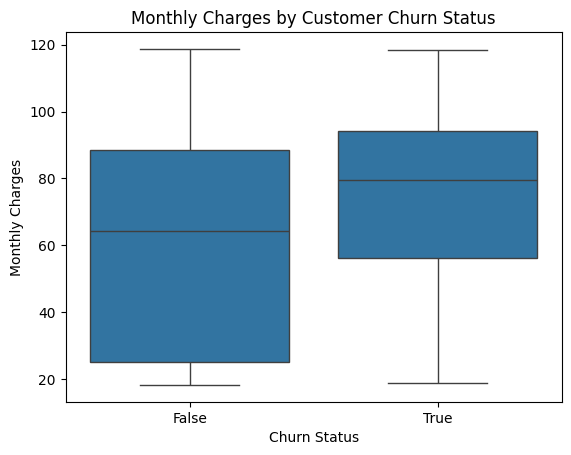

In [22]:
sns.boxplot(
    data=customer_churn,
    x='is_churned',
    y='monthly_charges'
)

plt.title('Monthly Charges by Customer Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.show()

### Initial Observation
* **Monthly charges** for churned customers are slightly higher than those for non-churned customers.
* This suggests that customers with **higher monthly charges may have a slightly greater tendency to churn.**
* However, the difference appears relatively small, so **monthly charges alone may not be a strong predictor of churn.**

## 5. Which cities have the highest churn rates among cities with a sufficient number of customers?

* For this analysis, we will consider cities with more than **100 customers** to have a sufficiently large customer base for meaningful analysis. 
* This threshold helps ensure that the findings are based on an adequate number of observations and are less likely to be influenced by small sample sizes.

In [23]:
city_churn = (
    customer_churn
    .groupby('city')
    .agg(
        customer_count=('is_churned', 'count'),
        churn_rate=('is_churned', lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Keep cities with more than 100 customers
cities_w_100 = city_churn[city_churn['customer_count'] > 100]

# Sort by churn rate
cities_w_100 = cities_w_100.sort_values(
    by='churn_rate',
    ascending=False
)

cities_w_100.head()

,city,customer_count,churn_rate
869,San Diego,150,33.333333
872,San Francisco,104,29.807692
562,Los Angeles,305,29.508197
878,San Jose,112,25.892857
855,Sacramento,108,24.074074


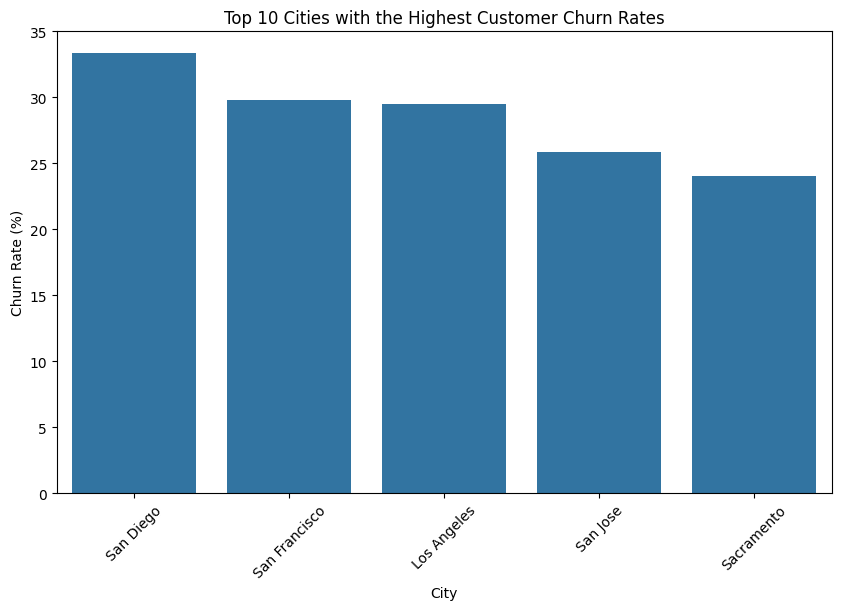

In [24]:
top_cities = cities_w_100.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_cities,
    x='city',
    y='churn_rate'
)

plt.xlabel('City')
plt.ylabel('Churn Rate (%)')
plt.title('Top 10 Cities with the Highest Customer Churn Rates')
plt.xticks(rotation=45)
plt.show()

### Initial Observation

* **San Deigo** has the highest customer churn rate among cities with more than **100 customers**, followed by **San Francisco**.

* These cities may require further investigation to identify the factors associated with their higher churn rates.

* By restricting the analysis to cities with more than **100 customers**, the results are less likely to be disproportionately influenced by small customer populations.

* Overall, geographic location may be associated with differences in customer churn and could provide useful insights for customer retention strategies.


## 6. Which type of internet service has the highest customer churn rate?

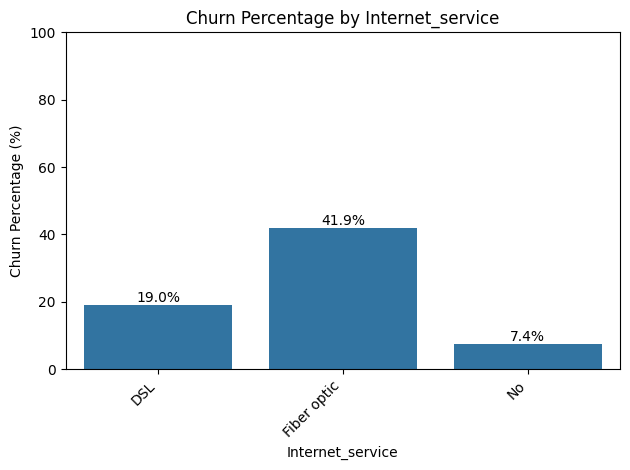

In [25]:
calculate_churn_percentage(customer_churn, 'internet_service')

### Initial Observations

* **Fiber optic customers** show a noticeably higher churn rate than customers using other types of internet service.

* This suggests a potential association between **internet service type and customer churn**. However, this relationship should not be interpreted as causal without further analysis, as factors such as **contract type, tenure, and monthly charges** may also influence churn and potentially explain part of the observed relationship.

* Overall, **internet service type appears to be a potentially important feature for predicting customer churn**.


## 7. Which additional service, excluding Phone Service, has the highest customer churn rate?

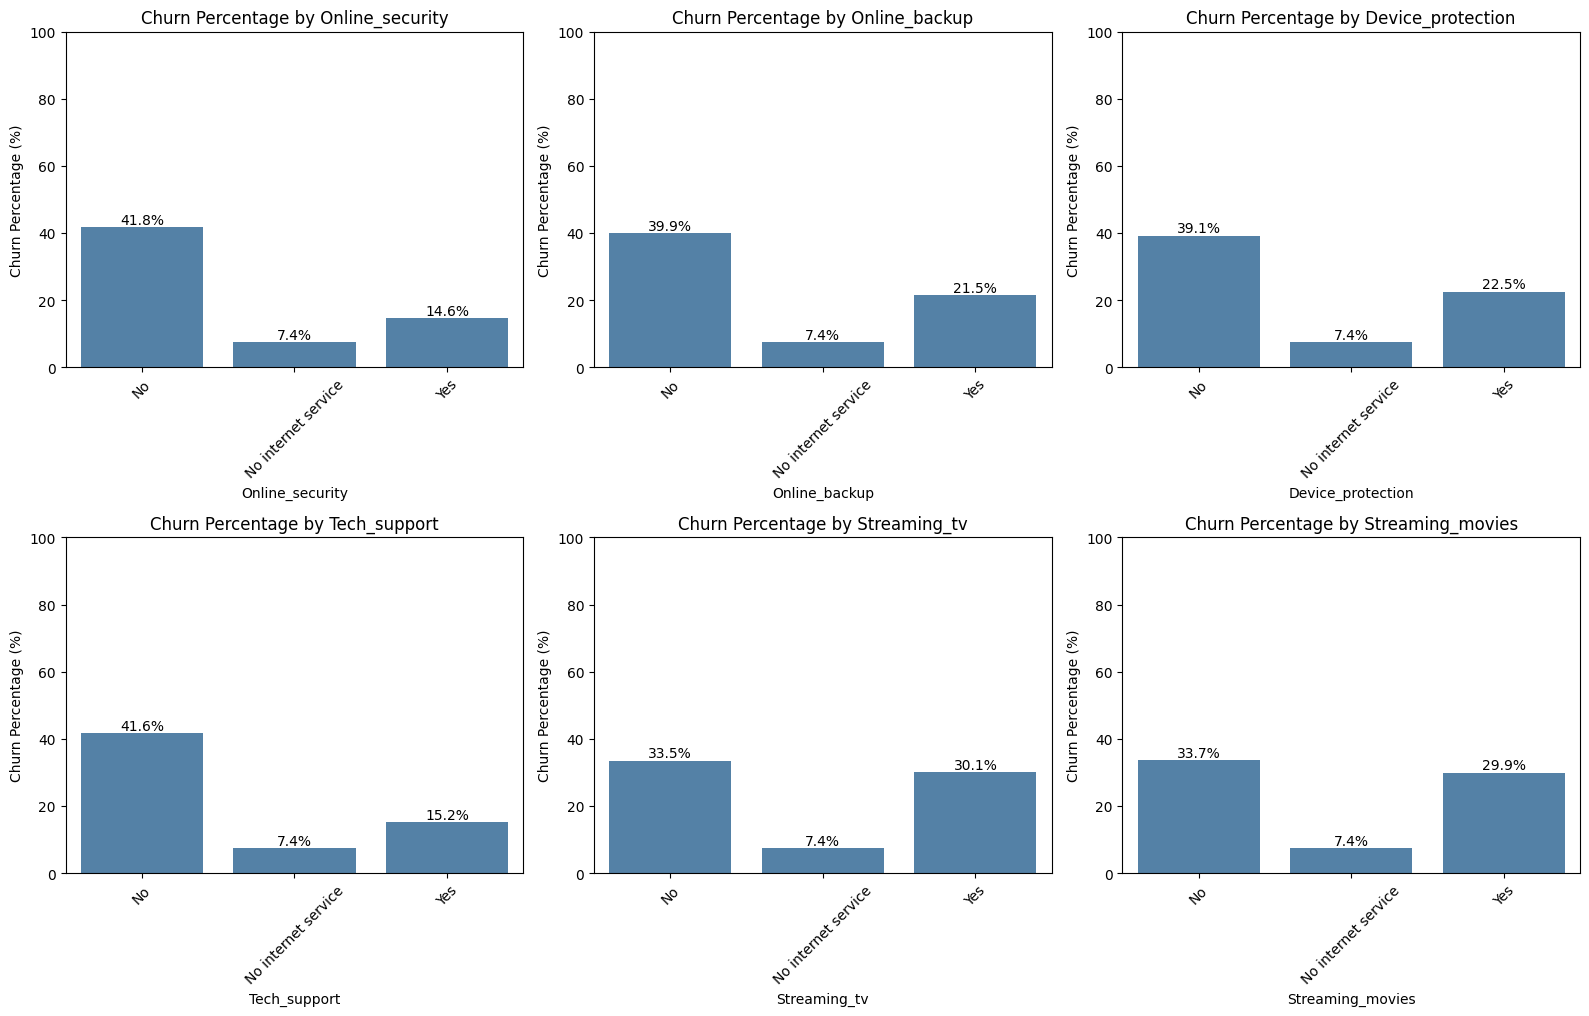

In [26]:
service_cols = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, column in enumerate(service_cols):

    churn_pct = (
        customer_churn
        .groupby(column)['churn_label']
        .apply(lambda x: (x == 'Yes').mean() * 100)
    )

    ax = axes[i]

    sns.barplot(
        x=churn_pct.index,
        y=churn_pct.values,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Churn Percentage by {capitalize_first(column)}')
    ax.set_xlabel(capitalize_first(column))
    ax.set_ylabel('Churn Percentage (%)')
    ax.set_ylim(0, 100)

    for j, value in enumerate(churn_pct.values):
        ax.text(
            j,
            value + 1,
            f'{value:.1f}%',
            ha='center'
        )

    ax.tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(service_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Initial Observations

* Customer churn rates show some variation across the additional services analyzed, although these services do not appear to demonstrate differences as substantial as those observed for factors such as contract type or internet service.

* Customers who do not subscribe to certain additional services may show higher churn rates than those who do, suggesting that some services could be associated with customer retention.

* However, these differences should be interpreted cautiously, as additional service subscriptions may be related to other factors such as contract type, tenure, monthly charges, and overall customer characteristics.

* Overall, additional services may provide useful information for predicting customer churn, but their individual relationship with churn may be weaker than some of the major factors identified in the earlier analysis.


## 8. What proportion of high-CLTV customers have churned?

For this analysis, customers in the **high** and **very high CLTV** quartiles are classified as **high-CLTV customers**. These groups represent the upper 50% of customers based on Customer Lifetime Value (CLTV).


In [27]:
customer_churn['cltv_band'] = pd.qcut(
    customer_churn['cltv'],
    q = 4,
    labels = ['low', 'medium', 'high', 'very_high']
)

In [28]:
high_cltv_customers = customer_churn[
    customer_churn['cltv_band'].isin(['high', 'very_high'])
]


In [29]:
high_cltv_customers.groupby('churn_label')

In [30]:
summary = (
    high_cltv_customers
    .groupby('churn_label')
    .size()
    .reset_index(name='count')
)

summary['percentage'] = summary['count'] / summary['count'].sum() * 100

summary


,churn_label,count,percentage
0,No,2731,77.563192
1,Yes,790,22.436808


### Initial Observations

* **Customer Retention:** Approximately **77.56%** of high-CLTV customers have not churned, indicating that the majority of high-value customers remain with the company.

* **Customer Churn:** Approximately **22.43%** of high-CLTV customers have churned. Although most high-value customers are retained, this represents a meaningful loss of valuable customers and may warrant further investigation.

* **Overall:** The churn of high-CLTV customers is particularly important from a business perspective because losing high-value customers may have a greater financial impact than losing lower-value customers.


In [31]:
customer_churn['cltv_band'].value_counts()

cltv_band
low          1763
very_high    1761
high         1760
medium       1759
Name: count, dtype: int64

## 9. Which tenure group has the highest percentage of churned customers? 

In [32]:
customer_churn['tenure_band'] = pd.qcut(
    customer_churn['tenure_months'],
    q = 4,
    labels = ['Very Short Tenure', 'Short Tenure', 'Long Tenure', 'Very Long Tenure']
)

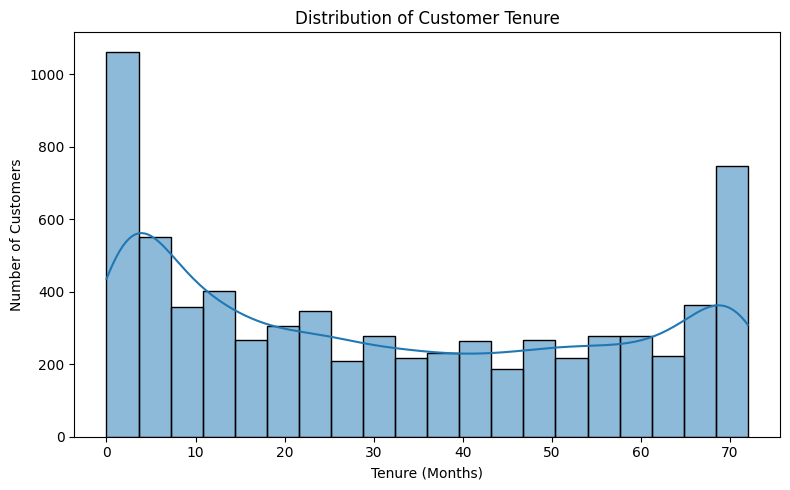

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=customer_churn,
    x='tenure_months',
    bins=20,
    kde=True
)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [34]:
tenure_churn = (
    customer_churn
    .groupby('tenure_band', observed=True)
    .agg(
        total_customers=('churn_label', 'count'),
        churned_customers=('churn_label', lambda x: (x == 'Yes').sum())
    )
    .reset_index()
)

tenure_churn['churn_rate'] = (
    tenure_churn['churned_customers'] /
    tenure_churn['total_customers'] * 100
).round(2)

tenure_churn

,tenure_band,total_customers,churned_customers,churn_rate
0,Very Short Tenure,1854,923,49.78
1,Short Tenure,1715,486,28.34
2,Long Tenure,1719,324,18.85
3,Very Long Tenure,1755,136,7.75


### Initial Observations

* **Very Short Tenure Customers:** Customers with a tenure of **0–9 months** have the highest churn rate at **49.38%**, meaning that nearly **1 in every 2 customers** in this tenure group has churned.

* This suggests that the risk of churn is particularly high during the early stages of the customer lifecycle.

* Overall, **customer tenure appears to have a strong association with churn**, with newer customers potentially requiring greater attention through early retention strategies.

* However, this relationship represents an association rather than causation and may also be influenced by factors such as **contract type, monthly charges, and service subscriptions**.

# Final Summary: Deep-Dive Customer Churn Analysis

The deep-dive exploratory analysis identified several important patterns and associations related to customer churn.

## 1. Customer Demographics

Gender showed relatively little difference in churn rates between male and female customers, suggesting that it may have a limited association with customer churn.

However, **senior-citizen status, partner status, and dependent status** showed more noticeable differences. Senior citizens generally had higher churn rates than non-senior customers, while customers without partners or dependents were more likely to churn.

The combined demographic analysis revealed particularly high churn among **senior citizens without partners (48.9%)** and **senior citizens without dependents (43.4%)**. In contrast, **non-senior customers with partners (16.6%)** and **non-senior customers with dependents (6.0%)** showed substantially lower churn rates.

These findings suggest that certain demographic characteristics and their combinations may be useful for identifying higher-risk customer segments.

## 2. Contract Type

Contract type demonstrated one of the strongest relationships with customer churn.

Customers on **month-to-month contracts had the highest churn rate (42.7%)**, compared with **11.3% for one-year contracts** and only **2.8% for two-year contracts**.

This indicates a strong association between longer contract durations and lower customer churn, making **contract type a potentially important feature for churn prediction and customer retention strategies**.

## 3. Monthly Charges

Churned customers had slightly higher monthly charges on average than retained customers.

This suggests that customers with higher monthly charges may have a greater tendency to churn. However, the difference between the groups appeared relatively small, indicating that **monthly charges alone may not be a strong predictor of churn**.

Monthly charges may provide more meaningful insights when analyzed alongside other variables such as contract type, tenure, and internet service.

## 4. Geographic Location

City-level churn analysis was restricted to cities with more than **100 customers** to reduce the influence of small sample sizes and produce more meaningful comparisons.

The analysis identified differences in churn rates across cities, suggesting that **geographic location may be associated with customer churn patterns**. Cities with higher churn rates may require further investigation to identify the customer, service, or market-related factors contributing to increased churn.

## 5. Internet Service

Customers using **fiber optic internet service** showed a noticeably higher churn rate than customers using other internet service types.

This indicates a potential association between internet service type and churn. However, this relationship should not be interpreted as causal because other factors—including **contract type, tenure, and monthly charges**—may also influence the observed churn pattern.

Overall, **internet service type appears to be a potentially important feature for predicting customer churn**.

## 6. Additional Services

The analysis of additional services—including online security, online backup, device protection, tech support, streaming TV, and streaming movies—showed variations in churn across service categories.

However, these differences were generally less substantial than those observed for major factors such as **contract type and internet service**.

Additional service subscriptions may still provide useful predictive information when combined with other customer characteristics, even if they are not strong standalone indicators of churn.

## 7. High-CLTV Customers

Customers in the **high and very high CLTV quartiles** were classified as high-CLTV customers for this analysis.

Approximately **77.56% of high-CLTV customers were retained**, while **22.43% had churned**.

Although most high-value customers remained with the company, the loss of more than one-fifth of high-CLTV customers represents a meaningful business concern because losing high-value customers can have a greater financial impact than losing lower-value customers.

## 8. Customer Tenure

The tenure analysis showed that customers with **very short tenure (0–9 months)** had the highest churn rate at **49.38%**.

This means that nearly **1 in every 2 customers** in this early stage of the customer lifecycle had churned.

The finding suggests that the risk of churn is particularly high among newer customers, making the **early customer lifecycle a critical period for retention efforts**.

Customer tenure therefore appears to be an important factor associated with churn and may be a valuable feature for machine learning models.

# Overall Conclusion

The deep-dive analysis indicates that customer churn is most strongly associated with several key factors, particularly:

* **Contract type**
* **Customer tenure**
* **Senior-citizen status**
* **Partner and dependent status**
* **Internet service type**
* **Monthly charges**
* **Customer Lifetime Value (CLTV)**

Among these factors, **month-to-month contracts, short customer tenure, senior-citizen status, and fiber optic internet service** emerged as important characteristics associated with higher customer churn.

These findings provide valuable business insights and establish a strong foundation for the next stage of the project: **feature engineering, machine learning model development, and identifying the most important predictors of customer churn**.

It is important to note that the relationships identified during this exploratory analysis represent **associations rather than causal relationships**. Further statistical analysis and machine learning techniques are required to evaluate the relative importance and predictive power of these features.

In [ ]:
# Processed Data Path
PROCESSED_DATA_PATH = Path("data/processed/customer_churn_clean_EDA_Deep_Dive.csv")
customer_churn.to_csv(PROCESSED_DATA_PATH)

In [ ]:
# Saving the cleaned dataset to Postgresql database
customer_churn.to_sql(
    "customer_churn_clean_eda_deep_dive",
    engine,
    if_exists="replace",
    index=False
)